This notebook has code to run the time trials against Optimal Transport.

In [1]:
import numpy as np, pandas as pd

from scipy.spatial.distance import pdist, squareform
import time, ot, gc

from scipy.stats import kendalltau, pearsonr, dirichlet

import matplotlib.pyplot as plt, seaborn as sns, matplotlib as mpl

from tools.core import *

# The algorithms

In [2]:
def pairwise_emd(P: np.ndarray, C: np.ndarray) -> np.ndarray:
    """
    Condensed pairwise exact OT (emd2) distances for rows of P with cost matrix C.
    Returns 1D condensed array like scipy.spatial.distance.pdist.
    """
    P = np.asarray(P, dtype=float)
    M, N = P.shape
    assert C.shape == (N, N)

    L = M * (M - 1) // 2
    if L == 0:
        return np.empty(0, dtype=float)

    out = np.empty(L, dtype=float)
    idx = 0
    for i in range(M - 1):
        a = P[i]
        for j in range(i + 1, M):
            b = P[j]
            out[idx] = ot.emd2(a, b, C)   # exact EMD^1 cost
            idx += 1
    return out

In [3]:
def pairwise_jbd_slow(P: np.ndarray, Z: np.ndarray, alpha: float) -> np.ndarray:
    """
    Condensed pairwise JB distances for rows of P with Z
    Returns 1D condensed array like scipy.spatial.distance.pdist.
    """
    P = np.asarray(P, dtype=float)
    M, N = P.shape
    assert Z.shape == (N, N)

    L = M * (M - 1) // 2
    if L == 0:
        return np.empty(0, dtype=float)

    out = np.empty(L, dtype=float)
    idx = 0
    for i in range(M - 1):
        a = P[i]
        for j in range(i + 1, M):
            b = P[j]
            out[idx] = get_entropy(Z, alpha, (a+b)/2) - 0.5*(get_entropy(Z, alpha, a) + get_entropy(Z, alpha, b))
            idx += 1
    return out

In [4]:
def pairwise_jbd_fast(P: np.ndarray, Z: np.ndarray, alpha: float, eps: float = 1e-16, block = None) -> np.ndarray:
    """
    Vectorised all-pairs Jensen-Bregman divergence.
    """
    assert alpha != 1.0
    P = np.asarray(P, dtype=float)
    Z = np.asarray(Z, dtype=float)
    M, N = P.shape
    assert Z.shape == (N, N)

    P = np.maximum(P, eps)
    row_sums = P.sum(axis=1, keepdims=True)
    if np.any(row_sums == 0):
        raise ValueError("Some rows of P sum to zero after clamping.")
    P = P / row_sums

    L = M * (M - 1) // 2
    if L == 0:
        return np.empty((0,), dtype=float)

    # heuristic block
    if block is None:
        approx = int(10_000_000 // max(1, M * N))
        block = max(1, min(M, approx))
    block = int(block)

    ZP = P @ Z
    ZP = np.maximum(ZP, eps) 

    if alpha == 2.0:
        # Quadratic fast branch
        pZp = np.einsum('ij,ij->i', P, ZP)   # (M,)
    else:
        a1 = alpha - 1.0
        ZP_a1 = ZP ** a1
        S_p = np.einsum('ij,ij->i', P, ZP_a1)   # (M,)

    cond = np.empty(L, dtype=float)

    # fill condensed vector in pdist ordering
    for i in range(0, M - 1):
        Pi = P[i]           # (N,)
        ZPi = ZP[i]         # (N,)
        if alpha == 2.0:
            pZp_i = pZp[i]
        else:
            S_p_i = S_p[i]

        j_start = i + 1
        for j0 in range(j_start, M, block):
            j1 = min(M, j0 + block)
            Q = P[j0:j1, :]          # (B, N)
            ZQ = ZP[j0:j1, :]        # (B, N)
            ZQ = np.maximum(ZQ, eps)

            if alpha == 2.0:
                # cross = p^T Z q  (using Z symmetric)
                cross = ZPi @ Q.T                  # (B,)
                pZp_js = pZp[j0:j1]               # (B,)
                # sum-of-divergences = (pZp_i + pZp_j - 2*cross)
                # Jensen-gap (mean divergence) = 0.5 * that.
                J_block = 0.5 * 0.5 * (pZp_i + pZp_js - 2.0 * cross)
                # same as 0.25*(pZp_i + pZp_js - 2*cross)
            else:
                # Zr = 0.5*(ZPi + ZQ) -> (B, N)
                Zr = 0.5 * (ZPi[None, :] + ZQ)
                Zr = np.maximum(Zr, eps)
                Zr_a1 = Zr ** a1

                # r = 0.5*(Pi + Q) -> (B, N)
                r = 0.5 * (Pi[None, :] + Q)

                S_r = np.einsum('ij,ij->i', r, Zr_a1)       # (B,)
                S_q_block = np.einsum('ij,ij->i', Q, ZQ ** a1)  # (B,)

                # Use Jensen-gap formula: (0.5*(S_p_i + S_q) - S_r) / a1
                J_block = (0.5 * (S_p_i + S_q_block) - S_r) / a1

            # store in condensed vector
            start_idx = i * M - (i * (i + 1)) // 2 + (j0 - i - 1)
            cond[start_idx:start_idx + (j1 - j0)] = J_block

    return cond

# Function to compare the time taken per run

We use the time module and disable the garbage collector to ensure accuracy.

In [5]:
def compare(P, C, Z, alpha, n_runs, verbose=False):
    'Returns [time OT, time JBD slow, time JBD fast, pearsonr, kendalltau]'

    result = []

    # OT
    gc.disable()
    start = time.perf_counter()
    for _ in range(n_runs):
        ot = pairwise_emd(P, C)
    end = time.perf_counter()
    result.append((end-start)/n_runs)
    gc.enable()

    if verbose:
        print(f'OT done: {result[-1]}')

    # JBD slow
    gc.disable()
    start = time.perf_counter()
    for _ in range(n_runs):
        jbd = pairwise_jbd_slow(P, Z, alpha)
    end = time.perf_counter()
    result.append((end-start)/n_runs)
    gc.enable()
    
    if verbose:
        print(f'JBD slow done: {result[-1]}')

    # JBD fast
    gc.disable()
    start = time.perf_counter()
    for _ in range(n_runs):
        jbd = pairwise_jbd_fast(P, Z, alpha)
    end = time.perf_counter()
    result.append((end-start)/n_runs)
    gc.enable()

    if verbose:
        print(f'JBD fast done: {result[-1]}')
    
    result.append( pearsonr(ot, jbd).statistic )
    result.append( kendalltau(ot, jbd).statistic )

    return result

In [6]:
def main(n_repeats, n_runs, N, M, alpha, e_dim=10, tau=1.):
    """
    n_repeats : int
        Number of datasets to generate and give to compare
    n_runs : int
        Passed on to compare
    N : int
        number of distributions
    M : int
        length of distributions
    alpha : float
    e_dim : int, default=10
        dimension of embedding vector
    tau : float, default=1
    """

    rng = np.random.default_rng()

    results = []

    for _ in range(n_repeats):
        # distributions are uniform

        P = dirichlet.rvs(alpha=[1.]*M, size=N)
        P /= P.sum(axis=1, keepdims=True)

        emb = rng.random((M, e_dim))
        C = squareform( pdist(emb) )
        Z = distance_to_similarity(C, tau)

        results.append(
            compare(P, C, Z, alpha, n_runs, verbose=False)
        )
    
    return results   


# Run experiment

In [7]:
input_sizes = np.array(np.logspace(2, 4, 3, base=np.sqrt(10)), dtype=int)
# np.array(np.logspace(2, 6, 5, base=np.sqrt(10)), dtype=int) in the paper.

In [8]:
dict_results = {N: None for N in input_sizes}
for N in dict_results:
    print(N)
    dict_results[N] = pd.DataFrame(
        main(n_repeats=10, n_runs=1, N=N, M=50, alpha=2, e_dim=10, tau=1.), # n_repeats=50 in the paper
        columns = ['ot', 'jbd_slow', 'jbd_fast', 'pearsonr', 'kendalltau']
    )

10
31
100


Text(0.5, 1.0, 'all pairs dissimilarity')

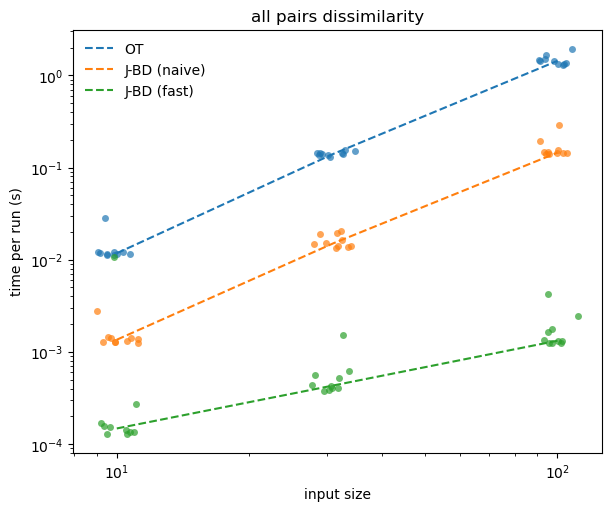

In [9]:
fig, ax = plt.subplots(1,1,figsize=(6, 5), layout='constrained')

for i, txt in enumerate(['ot', 'jbd_slow', 'jbd_fast']):
    temp = {N: dict_results[N][txt] for N in dict_results}
    sns.stripplot(
        temp, color=sns.color_palette()[i], log_scale=(True, True), native_scale=True, alpha=0.7, ax=ax, s=5, marker='o'
    )
    ax.plot(
        temp.keys(), [np.median(x) for x in temp.values()], color=sns.color_palette()[i], ls='--', label=['OT', 'J-BD (naive)', 'J-BD (fast)'][i]
    )
ax.legend(frameon=False,)
ax.set_xlabel('input size')
ax.set_ylabel('time per run (s)')
ax.set_title('all pairs dissimilarity')

# Data from the paper

In [10]:
import pickle
with open("outputs/synthetic/timetrial_M50_A2.pkl", "rb") as f:
    dict_results = pickle.load(f)

Text(0.5, 1.0, 'all pairs dissimilarity')

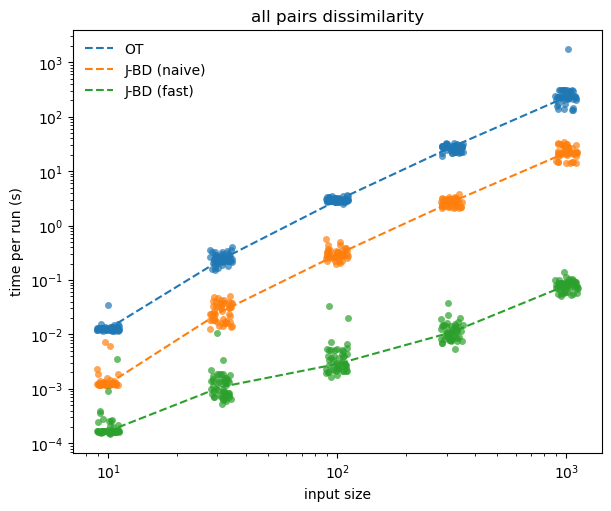

In [11]:
fig, ax = plt.subplots(1,1,figsize=(6, 5), layout='constrained')

for i, txt in enumerate(['ot', 'jbd_slow', 'jbd_fast']):
    temp = {N: dict_results[N][txt] for N in dict_results}
    sns.stripplot(
        temp , color=sns.color_palette()[i], log_scale=(True, True), native_scale=True, alpha=0.7, ax=ax, s=5, marker='o'
    )
    ax.plot(
        temp.keys(), [np.median(x) for x in temp.values()], color=sns.color_palette()[i], ls='--', label=['OT', 'J-BD (naive)', 'J-BD (fast)'][i]
    )
ax.legend(frameon=False,)
ax.set_xlabel('input size')
ax.set_ylabel('time per run (s)')
ax.set_title('all pairs dissimilarity')